# Email Spam Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


## Data Loading

In [2]:
df = pd.read_csv("email_spam_data.csv", encoding='latin1')
df = df.rename(columns={"Category": "label", "Message": "text"})

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.isnull().sum()


label    0
text     0
dtype: int64

In [4]:
df['label'].value_counts()


label
ham     4825
spam     747
Name: count, dtype: int64

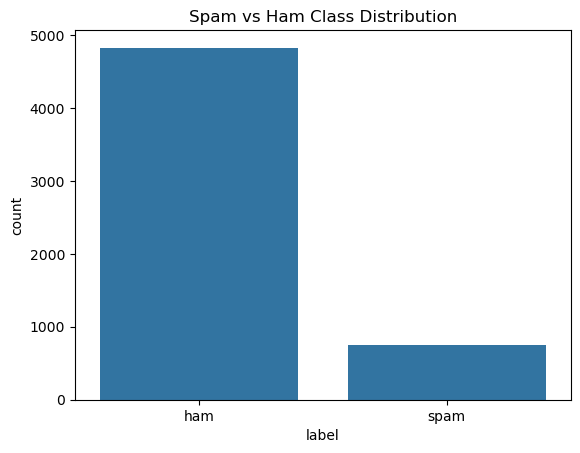

In [5]:
sns.countplot(data=df, x='label')
plt.title("Spam vs Ham Class Distribution")
plt.show()


## Encode label

In [6]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Text Preprocessing

In [7]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    
    # Step 3: Tokenization
    words = text.split()
    
    # Step 4: Remove stopwords and apply stemming
    filtered_words = [stemmer.stem(w) for w in words if w not in stop_words]
    
    # Step 5: Join words back into cleaned string
    return ' '.join(filtered_words)


In [8]:
df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## Train-Test Split

In [9]:
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


## Text Vectorization

In [10]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


## Naive Bayes Classifier 

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("Naive Bayes Classifier Results:")
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Naive Bayes Classifier Results:

Accuracy: 0.9668161434977578

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



## confusion_matrix

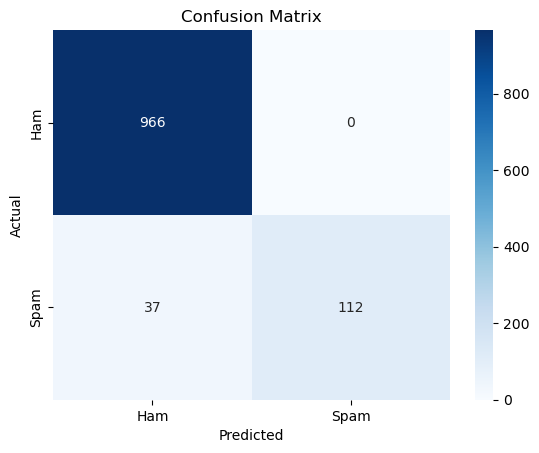

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Logistic Regression 

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train_vec, y_train)

y_pred_lr_model = lr_model.predict(X_test_vec)

print("Logistic Regression Results:")
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr_model))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_model))


Logistic Regression Results:

Accuracy: 0.97847533632287

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.91      0.93      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## Best Performer Model: Logistic Regression is Saved

In [14]:
import joblib

joblib.dump(lr_model, 'spam_classifier_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("Final model and vectorizer saved successfully.")


Final model and vectorizer saved successfully.
